# Edge-type Analysis - Rich, Feeder and Local connections
Code adapted from Alexa Mousley, edited by Maria B. Jelen

In [1]:
import os
import pandas as pd
import numpy as np
from netneurotools.networks import struct_consensus
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import bct
from joblib import Parallel, delayed
import warnings

In [2]:
# load data and align
membership_df = pd.read_csv('membership_df_cleaned.csv')
fmri_df = pd.read_csv('fmri_df_cleaned.csv')
analysis_df = pd.merge(membership_df, fmri_df, on='src_subject_id', how='inner')
print(f" {len(analysis_df)} participants have both fMRI and membership data.")

X_df_unthresholded = analysis_df.filter(like='edge_')

print(X_df_unthresholded.shape)

 4264 participants have both fMRI and membership data.
(4264, 4950)


In [3]:
# X_df - fMRI edges thresholded to 80%, participants x edges
# X_df_unthresholded - fMRI edges unthresholded, participants x edges
print(X_df_unthresholded.shape)

(4264, 4950)


In [4]:
X_df = pd.read_csv('fmri_threshold_80.csv')
X_df = X_df.sort_values(by='src_subject_id').reset_index(drop=True)
print(f"Number of NaN values in X_df: {X_df.isna().sum().sum()}")
X_h = X_df.drop('src_subject_id', axis=1).values

Number of NaN values in X_df: 0


In [5]:
# switch to participants x nodes x nodes

n_nodes = 100
triu_indices = np.triu_indices(n_nodes, k=1)

X_h = pd.DataFrame(X_h)

connectomes = np.zeros((X_h.shape[0], n_nodes, n_nodes))


# for each participants, reconstruct node x node matrix from upper triangle edges
for i in range(X_h.shape[0]):
    mat = np.zeros((n_nodes, n_nodes))
    mat[triu_indices] = X_h.iloc[i].values
    mat = mat + mat.T  # make symmetric
    connectomes[i] = mat

print(connectomes.shape)
print(pd.DataFrame(connectomes[0]).head())  # print the first participant's connectome to check alignment

connectomes = np.transpose(connectomes, (1, 2, 0))

print(connectomes.shape)

(4264, 100, 100)
         0         1         2         3         4         5         6   \
0  0.000000  0.807656  0.894686  0.000000  0.000000  0.000000  0.761342   
1  0.807656  0.000000  1.360555  0.938775  1.258698  1.128713  0.993064   
2  0.894686  1.360555  0.000000  0.746047  1.025047  1.485426  0.926525   
3  0.000000  0.938775  0.746047  0.000000  1.220004  0.000000  0.000000   
4  0.000000  1.258698  1.025047  1.220004  0.000000  1.134725  0.000000   

         7         8    9   ...   90   91   92        93   94   95   96   97  \
0  0.000000  0.000000  0.0  ...  0.0  0.0  0.0  0.736512  0.0  0.0  0.0  0.0   
1  1.258437  1.062776  0.0  ...  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   
2  1.126463  1.147976  0.0  ...  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   
3  1.102682  0.000000  0.0  ...  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   
4  1.114753  0.996324  0.0  ...  0.0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   

         98        99  
0  1.114778  0.717337  
1  

In [6]:
from nilearn import datasets

atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=100,
    yeo_networks=7,
    resolution_mm=2
)

atlas.maps  # atlas image
atlas.labels  # ROI names

[fetch_atlas_schaefer_2018] Dataset found in /Users/mj03/nilearn_data/schaefer_2018


['Background',
 '7Networks_LH_Vis_1',
 '7Networks_LH_Vis_2',
 '7Networks_LH_Vis_3',
 '7Networks_LH_Vis_4',
 '7Networks_LH_Vis_5',
 '7Networks_LH_Vis_6',
 '7Networks_LH_Vis_7',
 '7Networks_LH_Vis_8',
 '7Networks_LH_Vis_9',
 '7Networks_LH_SomMot_1',
 '7Networks_LH_SomMot_2',
 '7Networks_LH_SomMot_3',
 '7Networks_LH_SomMot_4',
 '7Networks_LH_SomMot_5',
 '7Networks_LH_SomMot_6',
 '7Networks_LH_DorsAttn_Post_1',
 '7Networks_LH_DorsAttn_Post_2',
 '7Networks_LH_DorsAttn_Post_3',
 '7Networks_LH_DorsAttn_Post_4',
 '7Networks_LH_DorsAttn_Post_5',
 '7Networks_LH_DorsAttn_Post_6',
 '7Networks_LH_DorsAttn_PrCv_1',
 '7Networks_LH_DorsAttn_FEF_1',
 '7Networks_LH_SalVentAttn_ParOper_1',
 '7Networks_LH_SalVentAttn_FrOperIns_1',
 '7Networks_LH_SalVentAttn_FrOperIns_2',
 '7Networks_LH_SalVentAttn_PFCl_1',
 '7Networks_LH_SalVentAttn_Med_1',
 '7Networks_LH_SalVentAttn_Med_2',
 '7Networks_LH_SalVentAttn_Med_3',
 '7Networks_LH_Limbic_OFC_1',
 '7Networks_LH_Limbic_TempPole_1',
 '7Networks_LH_Limbic_TempPole_2

In [7]:
from nilearn.plotting import find_parcellation_cut_coords

coords = find_parcellation_cut_coords(labels_img=atlas.maps)
print(coords.shape)

(100, 3)


In [8]:
from scipy.spatial.distance import pdist, squareform
dist_matrix = squareform(pdist(coords))

In [9]:
labels = atlas.labels[1:]  
hemiid = [0 if '_RH_' in label else 1 for label in labels]

print("Total ROIs:", len(labels))
print("Right hemi:", np.sum(np.array(hemiid)==0))
print("Left hemi:", np.sum(np.array(hemiid)==1))

Total ROIs: 100
Right hemi: 50
Left hemi: 50


In [10]:
hemiid = np.array(hemiid).reshape(-1, 1)
print(hemiid.shape)

(100, 1)


In [11]:
### create consensus matrix

consensus_network = struct_consensus(connectomes,dist_matrix,hemiid,conn_num_inter= 597, conn_num_intra=760,weighted=True)


#conn_num_inter= 600, conn_num_intra=760,
#conn_num_inter =568.2600844277673
#conn_num_intra =731.1078799249531

In [12]:
### create consensus matrix

connectomes_binary = (connectomes > 0).astype(int)
print(connectomes_binary.shape)

consensus_network = struct_consensus(connectomes_binary,dist_matrix,hemiid,weighted=False)

(100, 100, 4264)


In [13]:
print("Consensus unique values:", np.unique(consensus_network)[:10])
print("Subject unique values:", np.unique(connectomes_binary[0]))

Consensus unique values: [0 1]
Subject unique values: [0 1]


In [14]:
### Define rich club nodes through null models ###

null_sample = 100  # number of null models

# Calculate rich club coefs of consensus network
degree = bct.degrees_und(consensus_network)
max_degree = int(np.max(degree))
consensus_rich_coefs, _, _ = bct.rich_club_bu(consensus_network)

# Parallelize the function (can take a long time to run) #
def one_null(_):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        # Create null model with preserved degree distribution 
        null = bct.randmio_und(consensus_network, 10)[0] #bct.null_model_und_sign(consensus_network,20)[0] 

        # Calculate rich club coefficient for the null model
        rc = bct.rich_club_bu(null)[0]

    # Ensure rc is a 1D array
    rc = np.atleast_1d(rc)  # Converts scalar to 1-element array if needed
    # Prepare output array
    out = np.full(max_degree, np.nan)
    # Copy coefficients safely
    n_copy = min(len(rc), max_degree)
    out[:n_copy] = rc[:n_copy]

    return out

# Parallel computation of null models
null_rich_coefs = np.array(
    Parallel(n_jobs=-1, backend="threading")(
        delayed(one_null)(i) for i in range(null_sample)
    )
)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/bct/algorithms/core.py:515: RuntimeWarning: invalid value encountered in scalar divide
  R[k] = Ek[k] / (Nk[k] * (Nk[k] - 1))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/bct/algorithms/core.py:515: RuntimeWarning: invalid value encountered in scalar divide
  R[k] = Ek[k] / (Nk[k] * (Nk[k] - 1))


In [15]:
#### Determine inter and intra connections ####
# Print out what the default inter and intra-hemisphere connection number will be for the function if not pre-set
# use this to increase inter/intra connection number in consensus matrix function

from math import dist


num_node, _, num_sub = connectomes_binary.shape      # info on connectivity matrices
pos_data = connectomes_binary > 0                    # location of + values in matrix
pos_data_count = pos_data.sum(axis=2)  # num sub with + values at each node

with np.errstate(divide='ignore',
invalid='ignore'):

    average_weights = connectomes_binary.sum(axis=2) / pos_data_count

# empty array to hold inter/intra hemispheric connections

consensus = np.zeros((num_node, num_node, 2))

for conn_type in range(2):  # iterate through inter/intra hemisphere conn
    if conn_type == 0:      # get inter hemisphere edges
        inter_hemi = (hemiid == 0) @ (hemiid == 1).T
        keep_conn = np.logical_or(inter_hemi, inter_hemi.T)

    else:                   # get intra hemisphere edges
        right_hemi = (hemiid == 0) @ (hemiid == 0).T
        left_hemi = (hemiid == 1) @ (hemiid== 1).T
        keep_conn = np.logical_or(right_hemi @ right_hemi.T,left_hemi @ left_hemi.T)



    # mask the distance array for only those edges we want to examine

    full_dist_conn = dist_matrix * keep_conn
    upper_dist_conn = np.atleast_3d(np.triu(full_dist_conn))

    # generate array of weighted (by distance), positive edges across subs
    pos_dist = pos_data * upper_dist_conn
    pos_dist = pos_dist[np.nonzero(pos_dist)]

    # determine average # of positive edges across subs
    # we will use this to bin the edge weights

    if conn_type == 0:
       conn_num_inter = len(pos_dist) / num_sub
    else:
        conn_num_intra = len(pos_dist) / num_sub

print(f"conn_num_inter ={conn_num_inter}")
print(f"conn_num_intra ={conn_num_intra}")

conn_num_inter =568.2600844277673
conn_num_intra =731.1078799249531


In [16]:
def network_density(W):
    N = W.shape[0]
    n_edges = np.count_nonzero(W) / 2
    return n_edges / (N*(N-1)/2)

def mean_strength(W):
    return np.mean(bct.strengths_und(W))

def global_efficiency(W):
    return bct.efficiency_wei(W)


consensus_density = network_density(consensus_network)
consensus_strength = mean_strength(consensus_network)
consensus_efficiency = global_efficiency(consensus_network)

In [17]:
connectomes_binary_T = np.transpose(connectomes_binary, (2,0,1))

densities = []
strengths = []
efficiencies = []

for subject in (connectomes_binary_T):
    densities.append(network_density(subject))
    strengths.append(mean_strength(subject))
    efficiencies.append(global_efficiency(subject))

densities = np.array(densities)
strengths = np.array(strengths)
efficiencies = np.array(efficiencies)

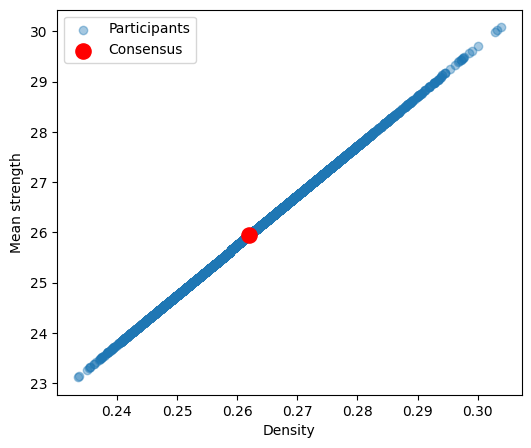

In [18]:
# density x strength plot with consensus point highlighted
plt.figure(figsize=(6,5))
plt.scatter(densities, strengths, alpha=0.4, label="Participants")
plt.scatter(consensus_density, consensus_strength, color="red", s=120, label="Consensus")
plt.xlabel("Density")
plt.ylabel("Mean strength")
plt.legend()
plt.show()

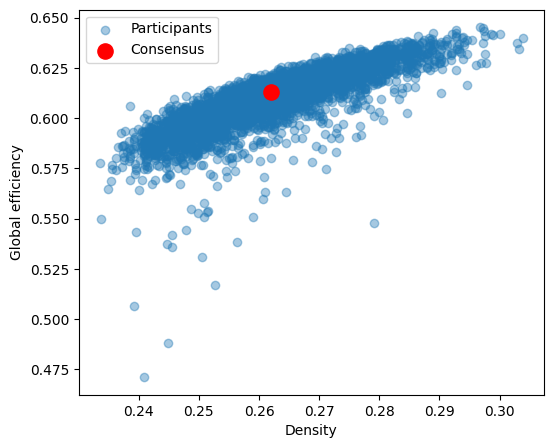

In [19]:
# density x efficiency plot with consensus point highlighted
plt.figure(figsize=(6,5))
plt.scatter(densities, efficiencies, alpha=0.4, label="Participants")
plt.scatter(consensus_density, consensus_efficiency, color="red", s=120, label="Consensus")
plt.xlabel("Density")
plt.ylabel("Global efficiency")
plt.legend()
plt.show()

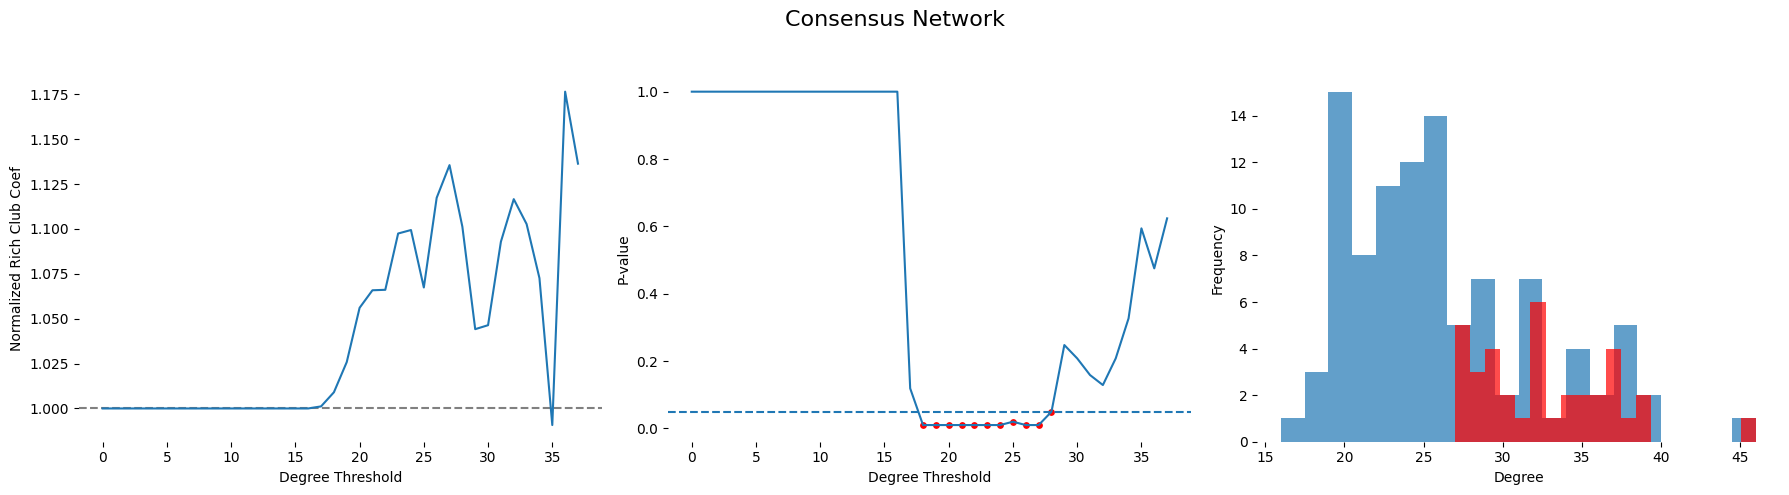

In [20]:
### Plot rich club data ###

# Calculate p-values 
p = np.zeros(max_degree)
for i in range(max_degree):
    n = null_rich_coefs[:, i]
    e = consensus_rich_coefs[i]
    n_valid = n[~np.isnan(n)]  # only consider valid null values

    if len(n_valid) == 0:
        p[i] = np.nan  # cannot compute p-value
    else:
        p[i] = (np.sum(n_valid >= e) + 1) / (len(n_valid) + 1)

# Calculate normalized rich club coefficients 
mean_rich_coefs = np.nanmean(null_rich_coefs, axis=0)
norm_rich_coefs = consensus_rich_coefs[:max_degree] / mean_rich_coefs

# Plot results 
plt.figure(figsize=(18, 5))
plt.suptitle('Consensus Network', fontsize=16)
# Normalized rich club coefficients
plt.subplot(1, 3, 1)
plt.axhline(1, linestyle='--', color='gray')
plt.plot(norm_rich_coefs)
plt.ylabel('Normalized Rich Club Coef')
plt.xlabel('Degree Threshold')
plt.tick_params(direction='out')
plt.box(False)
# P-values
plt.subplot(1, 3, 2)
plt.axhline(0.05, linestyle='--')
plt.plot(p)
sig_idx = np.where(p < 0.05)[0]
plt.scatter(sig_idx, p[sig_idx], color='red', s=15)
plt.ylabel('P-value')
plt.xlabel('Degree Threshold')
plt.tick_params(direction='out')
plt.box(False)
# Degree histogram (re-define the 'degree' based on the sig. degree values to see distrubtion)
plt.subplot(1, 3, 3)
plt.hist(degree, bins=20, alpha=0.7, label='All nodes')
plt.hist(degree[degree >= 27], bins=20, color='red', alpha=0.7, label='Rich club nodes')
plt.ylabel('Frequency')
plt.xlabel('Degree')
plt.tick_params(direction='out')
plt.box(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### DEFINE RICH CLUB NODES ###
rich_club = np.where(degree >= 27)[0] # <---------------- SET TO RIGHT DEGREE

In [21]:
for k in range(len(degree)):
    n_nodes = np.sum(degree >= k)
    print(k, n_nodes)

0 100
1 100
2 100
3 100
4 100
5 100
6 100
7 100
8 100
9 100
10 100
11 100
12 100
13 100
14 100
15 100
16 100
17 99
18 99
19 96
20 89
21 81
22 73
23 68
24 62
25 50
26 42
27 36
28 31
29 28
30 24
31 22
32 21
33 15
34 14
35 12
36 10
37 8
38 4
39 3
40 1
41 1
42 1
43 1
44 1
45 1
46 1
47 0
48 0
49 0
50 0
51 0
52 0
53 0
54 0
55 0
56 0
57 0
58 0
59 0
60 0
61 0
62 0
63 0
64 0
65 0
66 0
67 0
68 0
69 0
70 0
71 0
72 0
73 0
74 0
75 0
76 0
77 0
78 0
79 0
80 0
81 0
82 0
83 0
84 0
85 0
86 0
87 0
88 0
89 0
90 0
91 0
92 0
93 0
94 0
95 0
96 0
97 0
98 0
99 0


In [22]:
print(len(consensus_rich_coefs))
print(max_degree)
print(null_rich_coefs.shape)

46
46
(100, 46)


In [23]:
print("Nodes with degree >= 27:", np.sum(degree >= 27))
print("Total nodes:", len(degree))
print("Percentage:", np.mean(degree >= 27))

Nodes with degree >= 27: 36
Total nodes: 100
Percentage: 0.36


In [24]:
### Functions for exploring connection types ###


def count_connection_types(matrix, rich_nodes):
    # Convert list of indices to boolean mask
    rich_mask = np.zeros(matrix.shape[0], dtype=bool)
    rich_mask[rich_nodes] = True

    # Initialize counts
    rich = 0
    feeder = 0
    local = 0
    for i in range(matrix.shape[0]):
        for j in range(i + 1, matrix.shape[1]):  # upper triangle only
            if matrix[i, j] != 0:
                if rich_mask[i] and rich_mask[j]:
                    rich += 1
                elif rich_mask[i] or rich_mask[j]:
                    feeder += 1
                else:
                    local += 1

    return rich, feeder, local

def weight_connection_types(matrix, rich_nodes):
    # Convert list of indices to boolean mask
    rich_mask = np.zeros(matrix.shape[0], dtype=bool)
    rich_mask[rich_nodes] = True

    # Store weights by connection type
    rich_weights = []
    feeder_weights = []
    local_weights = []

    for i in range(matrix.shape[0]):
        for j in range(i + 1, matrix.shape[1]):  # upper triangle only
            w = matrix[i, j]
            if w != 0:
                if rich_mask[i] and rich_mask[j]:
                    rich_weights.append(w)
                elif rich_mask[i] or rich_mask[j]:
                    feeder_weights.append(w)
                else:
                    local_weights.append(w)
    return rich_weights, feeder_weights, local_weights

In [81]:
### Some basic print outs ###

# Calculate
con_rich, con_feeder, con_local = count_connection_types(consensus_network,rich_club)
con_rich_wei, con_feeder_wei, con_local_wei = weight_connection_types(consensus_network,rich_club)
total_connections = np.count_nonzero(consensus_network)/2

# Percentages
con_rich_per = np.round((con_rich*100)/total_connections,1)
con_feeder_per = np.round((con_feeder*100)/total_connections,1)
con_local_per = np.round((con_local*100)/total_connections,1)

print(total_connections)
print(con_rich)
# Print
print(f"Number of rich club nodes: {len(rich_club)}")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(con_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(con_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(con_local_wei),2)}\n")

1297.0
272
Number of rich club nodes: 36
Rich connections: 21.0%
Feeder connections: 48.3%
Local connections: 30.7%
Rich average weight: 1.0
Feeder averag weight: 1.0
Local average weight: 1.0



In [82]:
print(np.count_nonzero(consensus_network))

2594


### Load loading matrices and check enrichment for different types of connections

In [26]:
# load pls_membership_80_1000it model
import joblib

pls_membership_80_1000it = joblib.load('pls_membership_80_1000it.joblib')

print("\nVariance Explained (%):")
print(pls_membership_80_1000it.varexp * 100)

print("\nP-values:")
print(pls_membership_80_1000it.permres.pvals)


Variance Explained (%):
[28.32386514 18.56936876 15.54025318 12.65198809 12.11816298 11.46792309
  1.32843877]

P-values:
[0.000999   0.01198801 0.08691309 0.34665335 0.63436563 0.72327672
 0.5994006 ]


In [27]:
X_numeric = np.array(X_h, dtype=float)
new_x_loadings = pls_membership_80_1000it['x_weights'].copy()  # shape: (n_edges, n_LVs)
bootstrap_x_loadings = pls_membership_80_1000it['bootres']['x_weights_normed']  # shape: (n_edges, n_LVs)

for lv in range(pls_membership_80_1000it.x_scores.shape[1]):
    for i in range(X_numeric.shape[1]):
      new_x_loadings[i, lv] = np.corrcoef(X_numeric[:, i], pls_membership_80_1000it.x_scores[:, lv])[0, 1]

# results loadings calculated for LV1      
results_x_loadings_LV1 = pd.DataFrame({
    "Original_x_loadings" : new_x_loadings[:, 0],
    "BSR_LV1" : bootstrap_x_loadings [:, 0]
})

# LV2
results_x_loadings_LV2 = pd.DataFrame({
    "Original_x_loadings" : new_x_loadings[:, 1],
    "BSR_LV2" : bootstrap_x_loadings [:, 1]
})


print(new_x_loadings.shape)

(4950, 7)


In [28]:
n_nodes = 100
new_loading_matrix_LV1 = np.zeros((n_nodes, n_nodes))
triu_indices = np.triu_indices(n_nodes, k=1)
new_loading_matrix_LV1[triu_indices] = new_x_loadings[:, 0]
new_loading_matrix_LV1 = new_loading_matrix_LV1 + new_loading_matrix_LV1.T  # make symmetric

bsr_matrix_LV1 = np.zeros((n_nodes,n_nodes))
bsr_matrix_LV1[triu_indices] = bootstrap_x_loadings[:, 0]
bsr_matrix_LV1 = bsr_matrix_LV1 + bsr_matrix_LV1.T

print(new_loading_matrix_LV1.shape) # exp 100x100 after upper triangle reconstruction for Schaefer-100
#Mij​=corr(edgeij​ across participants, LV1 score)
print(bsr_matrix_LV1.shape)

(100, 100)
(100, 100)


In [29]:
n_nodes = 100
new_loading_matrix_LV2 = np.zeros((n_nodes, n_nodes))
triu_indices = np.triu_indices(n_nodes, k=1)
new_loading_matrix_LV2[triu_indices] = new_x_loadings[:, 1]
new_loading_matrix_LV2 = new_loading_matrix_LV2 + new_loading_matrix_LV2.T  # make symmetric

bsr_matrix_LV2 = np.zeros((n_nodes,n_nodes))
bsr_matrix_LV2[triu_indices] = bootstrap_x_loadings[:, 1]
bsr_matrix_LV2 = bsr_matrix_LV2 + bsr_matrix_LV2.T

print(new_loading_matrix_LV2.shape) # exp 100x100 after upper triangle reconstruction for Schaefer-100
#Mij​=corr(edgeij​ across participants, LV1 score)
print(bsr_matrix_LV2.shape)

(100, 100)
(100, 100)


In [30]:
# with significance defined by BSR > 1.96 akin to p < 0.05
# stability mask
stable_conn_LV1 = np.abs(bsr_matrix_LV1) > 1.96

# mask the loadings
masked_loadings_LV1 = np.where(stable_conn_LV1, new_loading_matrix_LV1, 0)

In [31]:
masked_loadings_LV1_binary = (np.abs(masked_loadings_LV1) > 0).astype(int)
print(masked_loadings_LV1_binary.shape)

(100, 100)


In [32]:
# with significance defined by BSR > 1.96 akin to p < 0.05
# stability mask
stable_conn_LV2 = np.abs(bsr_matrix_LV2) > 1.96

# mask the loadings
masked_loadings_LV2 = np.where(stable_conn_LV2, new_loading_matrix_LV2, 0)

In [33]:
masked_loadings_LV2_binary = (np.abs(masked_loadings_LV2) > 0).astype(int)
print(masked_loadings_LV2_binary.shape)

(100, 100)


In [75]:
# LV1 thresholded by |BSR| > 1.96 - weighted

# Calculate
LV1_rich_thresh, LV1_feeder_thresh, LV1_local_thresh = count_connection_types(masked_loadings_LV1,rich_club)
LV1_rich_wei_thresh, LV1_feeder_wei_thresh, LV1_local_wei_thresh = weight_connection_types(masked_loadings_LV1,rich_club)
total_connections = np.count_nonzero(masked_loadings_LV1)/2

# Percentages
LV1_con_rich_per_thresh = np.round((LV1_rich_thresh*100)/total_connections,1)
LV1_con_feeder_per_thresh = np.round((LV1_feeder_thresh*100)/total_connections,1)
LV1_con_local_per_thresh = np.round((LV1_local_thresh*100)/total_connections,1)

# Print
# print(f"Number of rich club nodes: {len(rich_club)}")
print(f"Total non-zero connections: {total_connections}")

print(f"LV 1 connection types:")
print(f"Rich connections: {LV1_con_rich_per_thresh}%")
print(f"Feeder connections: {LV1_con_feeder_per_thresh}%")
print(f"Local connections: {LV1_con_local_per_thresh}%")
print(f"Rich average weight: {np.round(np.mean(LV1_rich_wei_thresh),2)}")
print(f"Feeder average weight: {np.round(np.mean(LV1_feeder_wei_thresh),2)}")
print(f"Local average weight: {np.round(np.mean(LV1_local_wei_thresh),2)}\n")

Total non-zero connections: 545.0
LV 1 connection types:
Rich connections: 21.1%
Feeder connections: 47.0%
Local connections: 31.9%
Rich average weight: 0.22
Feeder average weight: 0.18
Local average weight: 0.09



In [35]:
print(LV1_rich)

115


In [36]:
# LV1 thresholded by |BSR| > 1.96 binary

# Calculate
LV1_rich, LV1_feeder, LV1_local = count_connection_types(masked_loadings_LV1_binary,rich_club)
LV1_rich_wei, LV1_feeder_wei, LV1_local_wei = weight_connection_types(masked_loadings_LV1_binary,rich_club)
total_connections = np.count_nonzero(masked_loadings_LV1_binary)/2

# Percentages
con_rich_per = np.round((LV1_rich*100)/total_connections,1)
con_feeder_per = np.round((LV1_feeder*100)/total_connections,1)
con_local_per = np.round((LV1_local*100)/total_connections,1)

# Print
# print(f"Number of rich club nodes: {len(rich_club)}")

print(f"LV 1 connection types:")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(LV1_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(LV1_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(LV1_local_wei),2)}\n")

LV 1 connection types:
Rich connections: 21.1%
Feeder connections: 47.0%
Local connections: 31.9%
Rich average weight: 1.0
Feeder averag weight: 1.0
Local average weight: 1.0



In [37]:
# LV1 unthresholded - weighted

# Calculate
LV1_rich, LV1_feeder, LV1_local = count_connection_types(new_loading_matrix_LV1,rich_club)
LV1_rich_wei, LV1_feeder_wei, LV1_local_wei = weight_connection_types(new_loading_matrix_LV1,rich_club)
total_connections = np.count_nonzero(new_loading_matrix_LV1)/2

# Percentages
con_rich_per = np.round((LV1_rich*100)/total_connections,1)
con_feeder_per = np.round((LV1_feeder*100)/total_connections,1)
con_local_per = np.round((LV1_local*100)/total_connections,1)

# Print
print(f"Number of rich club nodes: {len(rich_club)}")

print(f"LV 1 connection types:")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(LV1_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(LV1_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(LV1_local_wei),2)}\n")

Number of rich club nodes: 36
LV 1 connection types:
Rich connections: 12.7%
Feeder connections: 46.5%
Local connections: 40.7%
Rich average weight: 0.13
Feeder averag weight: 0.08
Local average weight: 0.02



In [38]:
raw_loadings_LV1_binary = (np.abs(new_loading_matrix_LV1) > 0).astype(int)
print(raw_loadings_LV1_binary.shape)

(100, 100)


In [39]:
# LV1 unthresholded - binary

# Calculate
LV1_rich, LV1_feeder, LV1_local = count_connection_types(raw_loadings_LV1_binary,rich_club)
LV1_rich_wei, LV1_feeder_wei, LV1_local_wei = weight_connection_types(raw_loadings_LV1_binary,rich_club)
total_connections = np.count_nonzero(raw_loadings_LV1_binary)/2

# Percentages
con_rich_per = np.round((LV1_rich*100)/total_connections,1)
con_feeder_per = np.round((LV1_feeder*100)/total_connections,1)
con_local_per = np.round((LV1_local*100)/total_connections,1)

# Print
print(f"Number of rich club nodes: {len(rich_club)}")

print(f"LV 1 connection types:")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(LV1_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(LV1_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(LV1_local_wei),2)}\n")

Number of rich club nodes: 36
LV 1 connection types:
Rich connections: 12.7%
Feeder connections: 46.5%
Local connections: 40.7%
Rich average weight: 1.0
Feeder averag weight: 1.0
Local average weight: 1.0



Edge types and weights - LV2

In [74]:
# LV2 thresholded by |BSR| > 1.96 - weighted

# Calculate
LV2_rich_thresh, LV2_feeder_thresh, LV2_local_thresh = count_connection_types(masked_loadings_LV2,rich_club)
LV2_rich_wei_thresh, LV2_feeder_wei_thresh, LV2_local_wei_thresh = weight_connection_types(masked_loadings_LV2,rich_club)
total_connections = np.count_nonzero(masked_loadings_LV2)/2

# Percentages
LV2_con_rich_per_thresh = np.round((LV2_rich_thresh*100)/total_connections,1)
LV2_con_feeder_per_thresh = np.round((LV2_feeder_thresh*100)/total_connections,1)
LV2_con_local_per_thresh = np.round((LV2_local_thresh*100)/total_connections,1)

# Print
print(f"Number of rich club nodes: {len(rich_club)}")
print(f"Total non-zeroconnections: {total_connections}")

print(f"Rich connections: {LV2_con_rich_per_thresh}%")
print(f"Feeder connections: {LV2_con_feeder_per_thresh}%")
print(f"Local connections: {LV2_con_local_per_thresh}%")
print(f"Rich average weight: {np.round(np.mean(LV2_rich_wei_thresh),2)}")
print(f"Feeder average weight: {np.round(np.mean(LV2_feeder_wei_thresh),2)}")
print(f"Local average weight: {np.round(np.mean(LV2_local_wei_thresh),2)}\n")

Number of rich club nodes: 36
Total non-zeroconnections: 459.0
Rich connections: 19.4%
Feeder connections: 40.5%
Local connections: 40.1%
Rich average weight: 0.3
Feeder average weight: 0.22
Local average weight: 0.15



In [41]:
# LV2 unthresholded - weighted

# Calculate
LV2_rich, LV2_feeder, LV2_local = count_connection_types(new_loading_matrix_LV2,rich_club)
LV2_rich_wei, LV2_feeder_wei, LV2_local_wei = weight_connection_types(new_loading_matrix_LV2,rich_club)
total_connections = np.count_nonzero(new_loading_matrix_LV2)/2

# Percentages
con_rich_per = np.round((LV2_rich*100)/total_connections,1)
con_feeder_per = np.round((LV2_feeder*100)/total_connections,1)
con_local_per = np.round((LV2_local*100)/total_connections,1)

# Print
print(f"Number of rich club nodes: {len(rich_club)}")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(LV2_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(LV2_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(LV2_local_wei),2)}\n")

Number of rich club nodes: 36
Rich connections: 12.7%
Feeder connections: 46.5%
Local connections: 40.7%
Rich average weight: 0.21
Feeder averag weight: 0.15
Local average weight: 0.12



In [42]:
raw_loadings_LV2_binary = (np.abs(new_loading_matrix_LV2) > 0).astype(int)
print(raw_loadings_LV2_binary.shape)

(100, 100)


In [43]:
# LV2 thresholded by |BSR| > 1.96

# Calculate
LV2_rich, LV2_feeder, LV2_local = count_connection_types(masked_loadings_LV2_binary,rich_club)
LV2_rich_wei, LV2_feeder_wei, LV2_local_wei = weight_connection_types(masked_loadings_LV2_binary,rich_club)
total_connections = np.count_nonzero(masked_loadings_LV2_binary)/2

# Percentages
con_rich_per = np.round((LV2_rich*100)/total_connections,1)
con_feeder_per = np.round((LV2_feeder*100)/total_connections,1)
con_local_per = np.round((LV2_local*100)/total_connections,1)

# Print
print(f"Number of rich club nodes: {len(rich_club)}")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(LV2_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(LV2_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(LV2_local_wei),2)}\n")

Number of rich club nodes: 36
Rich connections: 19.4%
Feeder connections: 40.5%
Local connections: 40.1%
Rich average weight: 1.0
Feeder averag weight: 1.0
Local average weight: 1.0



In [44]:
# LV2 unthresholded

# Calculate
LV2_rich, LV2_feeder, LV2_local = count_connection_types(raw_loadings_LV2_binary,rich_club)
LV2_rich_wei, LV2_feeder_wei, LV2_local_wei = weight_connection_types(raw_loadings_LV2_binary,rich_club)
total_connections = np.count_nonzero(raw_loadings_LV2_binary)/2

# Percentages
con_rich_per = np.round((LV2_rich*100)/total_connections,1)
con_feeder_per = np.round((LV2_feeder*100)/total_connections,1)
con_local_per = np.round((LV2_local*100)/total_connections,1)

# Print
print(f"Number of rich club nodes: {len(rich_club)}")
print(f"Rich connections: {con_rich_per}%")
print(f"Feeder connections: {con_feeder_per}%")
print(f"Local connections: {con_local_per}%")
print(f"Rich average weight: {np.round(np.mean(LV2_rich_wei),2)}")
print(f"Feeder averag weight: {np.round(np.mean(LV2_feeder_wei),2)}")
print(f"Local average weight: {np.round(np.mean(LV2_local_wei),2)}\n")

Number of rich club nodes: 36
Rich connections: 12.7%
Feeder connections: 46.5%
Local connections: 40.7%
Rich average weight: 1.0
Feeder averag weight: 1.0
Local average weight: 1.0



In [77]:
# contingency table
cont_table = pd.DataFrame({
    "rich" : [LV1_rich_thresh, LV2_rich_thresh],
    "feeder" : [LV1_feeder_thresh, LV2_feeder_thresh],
    "local" : [LV1_local_thresh, LV2_local_thresh]
}, index = ["LV1", "LV2"])

In [78]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cont_table)
print("Chi-squared:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-squared: 7.36654378071502
P-value: 0.025140582889285154
Degrees of freedom: 2
Expected frequencies:
 [[110.73705179 239.93027888 194.33266932]
 [ 93.26294821 202.06972112 163.66733068]]


In [79]:
residuals = (cont_table - expected) / np.sqrt(expected)
print(residuals)

         rich    feeder     local
LV1  0.405101  1.037447 -1.458551
LV2 -0.441424 -1.130467  1.589327


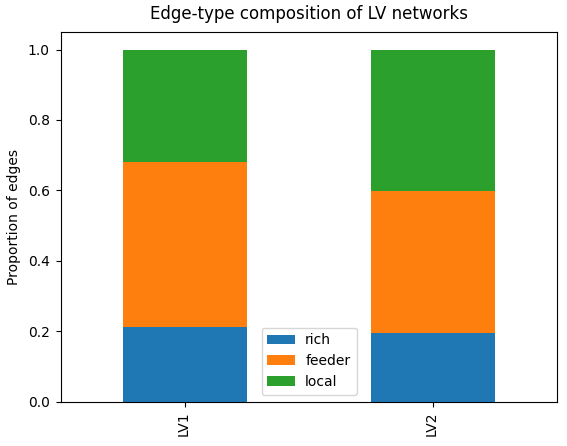

In [80]:
prop_table = cont_table.div(cont_table.sum(axis=1), axis=0)
prop_table.plot(kind="bar", stacked=True)

plt.ylabel("Proportion of edges")
plt.title("Edge-type composition of LV networks")
plt.show()

In [83]:
# contingency table - with consensus
cont_table_cons = pd.DataFrame({
    "rich" : [LV1_rich_thresh, LV2_rich_thresh, con_rich],
    "feeder" : [LV1_feeder_thresh, LV2_feeder_thresh, con_feeder],
    "local" : [LV1_local_thresh, LV2_local_thresh, con_local]
}, index = ["LV1", "LV2", "consensus"])

In [84]:
chi2, p, dof, expected = chi2_contingency(cont_table_cons)
print("Chi-squared:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-squared: 14.278575549008146
P-value: 0.0064570346743795665
Degrees of freedom: 4
Expected frequencies:
 [[112.74228596 253.19643633 179.06127771]
 [ 94.9517601  213.24250326 150.80573664]
 [268.30595393 602.56106041 426.13298566]]


### Print where the rich clubs are

In [45]:
rich_labels = [atlas.labels[i] for i in rich_club]
for i, lab in zip(rich_club, rich_labels):
    print(i, lab)

6 7Networks_LH_Vis_6
9 7Networks_LH_Vis_9
14 7Networks_LH_SomMot_5
15 7Networks_LH_SomMot_6
19 7Networks_LH_DorsAttn_Post_4
21 7Networks_LH_DorsAttn_Post_6
22 7Networks_LH_DorsAttn_PrCv_1
23 7Networks_LH_DorsAttn_FEF_1
26 7Networks_LH_SalVentAttn_FrOperIns_2
27 7Networks_LH_SalVentAttn_PFCl_1
28 7Networks_LH_SalVentAttn_Med_1
29 7Networks_LH_SalVentAttn_Med_2
33 7Networks_LH_Limbic_TempPole_2
39 7Networks_LH_Default_Temp_2
40 7Networks_LH_Default_Par_1
43 7Networks_LH_Default_PFC_2
45 7Networks_LH_Default_PFC_4
46 7Networks_LH_Default_PFC_5
47 7Networks_LH_Default_PFC_6
49 7Networks_LH_Default_pCunPCC_1
52 7Networks_RH_Vis_2
58 7Networks_RH_Vis_8
59 7Networks_RH_SomMot_1
66 7Networks_RH_SomMot_8
69 7Networks_RH_DorsAttn_Post_3
71 7Networks_RH_DorsAttn_Post_5
72 7Networks_RH_DorsAttn_PrCv_1
73 7Networks_RH_DorsAttn_FEF_1
76 7Networks_RH_SalVentAttn_FrOperIns_1
77 7Networks_RH_SalVentAttn_Med_1
81 7Networks_RH_Cont_Par_1
85 7Networks_RH_Cont_PFCl_3
87 7Networks_RH_Cont_Cing_1
90 7Network

[fetch_atlas_schaefer_2018] Dataset found in /Users/mj03/nilearn_data/schaefer_2018


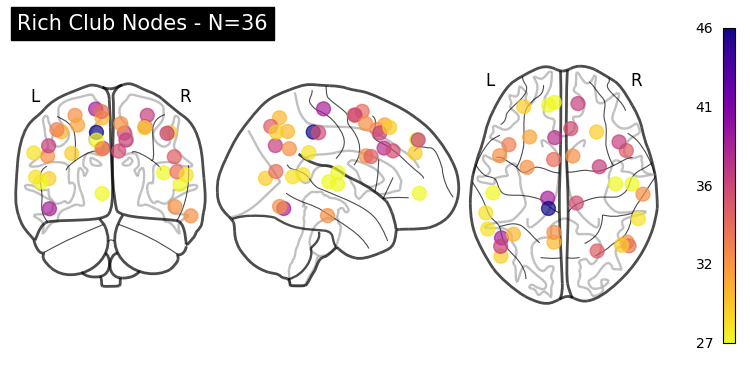

In [46]:
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.plotting import plot_markers
import numpy as np

atlas = fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7, resolution_mm=2)



plot_markers(
    node_coords = coords[rich_club],
    node_values = degree[rich_club],
    title="Rich Club Nodes - N=36",
    node_cmap = 'plasma_r'
)


In [47]:
from collections import Counter

nets = [atlas.labels[i].split("_")[2] for i in rich_club]
print(Counter(nets))

Counter({'Default': 10, 'DorsAttn': 8, 'SalVentAttn': 6, 'Vis': 4, 'SomMot': 4, 'Cont': 3, 'Limbic': 1})


Enrichment of rich edges in LV1 and LV2

In [48]:
def density(matrix):
    iu = np.triu_indices(matrix.shape[0], 1)
    return np.sum(matrix[iu] != 0) / len(iu[0])

print("Density LV1:", density(masked_loadings_LV1_binary))
print("Density LV2:", density(masked_loadings_LV2_binary))

Density LV1: 0.1101010101010101
Density LV2: 0.09272727272727273


In [49]:
iu = np.triu_indices(masked_loadings_LV1_binary.shape[0], 1)

n_edges1 = np.sum(masked_loadings_LV1_binary[iu])
n_edges2 = np.sum(masked_loadings_LV2_binary[iu])

n_nodes = masked_loadings_LV1_binary.shape[0]
n_possible = len(iu[0])

In [50]:
def rich_proportion(matrix, rich_nodes):
    rich, feeder, local = count_connection_types(matrix, rich_nodes)
    total = rich + feeder + local
    return rich / total if total > 0 else np.nan

obs_diff = (
    rich_proportion(masked_loadings_LV1_binary, rich_club)
    - rich_proportion(masked_loadings_LV2_binary, rich_club)
)

print("Observed difference:", obs_diff)

Observed difference: 0.01710939217685037


In [51]:
def random_graph_with_n_edges(n_nodes, n_edges):
    iu = np.triu_indices(n_nodes, 1)
    mat = np.zeros((n_nodes, n_nodes))

    chosen = np.random.choice(len(iu[0]), n_edges, replace=False)
    mat[iu[0][chosen], iu[1][chosen]] = 1
    mat = mat + mat.T
    return mat


n_perm = 5000
null_diffs = np.zeros(n_perm)

for p in range(n_perm):

    perm_W1 = random_graph_with_n_edges(n_nodes, n_edges1)
    perm_W2 = random_graph_with_n_edges(n_nodes, n_edges2)

    null_diffs[p] = (
        rich_proportion(perm_W1, rich_club)
        - rich_proportion(perm_W2, rich_club)
    )

In [52]:
p_value = np.mean(np.abs(null_diffs) >= np.abs(obs_diff))
print("Permutation p-value:", p_value)

Permutation p-value: 0.3812


Plotting connections on chord plot, colored by type

In [53]:
from nilearn import datasets
from nilearn import plotting

schaefer_atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7, resolution_mm=2)
schaefer_labels = schaefer_atlas.labels
atlas_filename = schaefer_atlas.maps
node_coords = plotting.find_parcellation_cut_coords(labels_img=atlas_filename)

[fetch_atlas_schaefer_2018] Dataset found in /Users/mj03/nilearn_data/schaefer_2018


In [54]:
# convenience function to extract from matrix
from nichord.convert import convert_matrix

edges, edge_weights = convert_matrix(masked_loadings_LV1)

In [55]:
edges = [(i, j) for i, j in edges if i != 0 and j != 0]
edge_weights = [
    w for (i, j), w in zip(edges, edge_weights) if i != 0 and j != 0
]

edges = [tuple(map(int, e)) for e in edges]
edge_weights = [float(w) for w in edge_weights]

In [56]:
def classify_edges(edges, rich_nodes, n_nodes):
    # create boolean mask of rich nodes
    rich_mask = np.zeros(n_nodes, dtype=bool)
    rich_mask[rich_nodes] = True

    new_edge_weights = []

    for i, j in edges:
        if rich_mask[i] and rich_mask[j]:
            new_edge_weights.append(0.5)     # rich
        elif rich_mask[i] or rich_mask[j]:
            new_edge_weights.append(0.35)     # feeder
        else:
            new_edge_weights.append(-0.1)    # local

    return new_edge_weights

In [57]:
new_edge_weights = classify_edges(
    edges,
    rich_club,
    n_nodes=masked_loadings_LV1.shape[0]
)

In [58]:
def extract_network(label):
    if label == "Background":
        return None
    return label.split("_")[2]

idx_to_label = {
    i-1:extract_network(label)
    for i, label in enumerate(schaefer_labels)
    if i !=0
}

In [59]:
network_colors = {"Vis": "#785EF0",
                  "SomMot": "#000000",
                  "SalVentAttn": "#009E73",
                  "Limbic":"#FE6100",
                  "DorsAttn":"#FFB000",
                  "Default":"#DC267F",
                  "Cont":"#00B8FF"

}

In [60]:
from nichord.chord import plot_chord
fp_chord = 'Chord_LV1_conntypes.png'
plot_chord(
    idx_to_label,
    edges,
    edge_weights=new_edge_weights,
    network_colors=network_colors,
    linewidths=2,
    alphas=0.7,
    fp_chord=fp_chord,
    vmin=-.2,
    vmax=0.6
)

<Figure size 1500x1500 with 0 Axes>

In [61]:
# LV2 conn types
edges, edge_weights = convert_matrix(masked_loadings_LV2)

In [62]:
edges = [(i, j) for i, j in edges if i != 0 and j != 0]
edge_weights = [
    w for (i, j), w in zip(edges, edge_weights) if i != 0 and j != 0
]

edges = [tuple(map(int, e)) for e in edges]
edge_weights = [float(w) for w in edge_weights]

In [63]:
new_edge_weights2 = classify_edges(
    edges,
    rich_club,
    n_nodes=masked_loadings_LV2.shape[0]
)

In [64]:
from nichord.chord import plot_chord
fp_chord = 'Chord_LV2_conntypes.png'
plot_chord(
    idx_to_label,
    edges,
    edge_weights=new_edge_weights2,
    network_colors=network_colors,
    linewidths=2,
    alphas=0.7,
    fp_chord=fp_chord,
    vmin=-.2,
    vmax=0.6
)

<Figure size 1500x1500 with 0 Axes>